# Data Cleaning

In [20]:
# import 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

# Read Dataset

In [13]:
# Read Dataset
fies_df = pd.read_csv("../data/raw/Family Income and Expenditure.csv")

print("Dataset:")
print(fies_df.shape)
fies_df.head()

Dataset:
(41544, 60)


,Total Household Income,Region,Total Food Expenditure,Main Source of Income,Agricultural Household indicator,Bread and Cereals Expenditure,Total Rice Expenditure,Meat Expenditure,Total Fish and marine products Expenditure,Fruit Expenditure,...,Number of Refrigerator/Freezer,Number of Washing Machine,Number of Airconditioner,"Number of Car, Jeep, Van",Number of Landline/wireless telephones,Number of Cellular phone,Number of Personal Computer,Number of Stove with Oven/Gas Range,Number of Motorized Banca,Number of Motorcycle/Tricycle
0,480332,CAR,117848,Wage/Salaries,0,42140,38300,24676,16806,3325,...,1,1,0,0,0,2,1,0,0,1
1,198235,CAR,67766,Wage/Salaries,0,17329,13008,17434,11073,2035,...,0,1,0,0,0,3,1,0,0,2
2,82785,CAR,61609,Wage/Salaries,1,34182,32001,7783,2590,1730,...,0,0,0,0,0,0,0,0,0,0
3,107589,CAR,78189,Wage/Salaries,0,34030,28659,10914,10812,690,...,0,0,0,0,0,1,0,0,0,0
4,189322,CAR,94625,Wage/Salaries,0,34820,30167,18391,11309,1395,...,1,0,0,0,0,3,0,0,0,1


# Check for Missing Data

In [7]:
missing = fies_df.isnull().sum()
missing = missing[missing > 0]

print("Check for Missing Data")
print(missing)

Check for Missing Data
Household Head Class of Worker    7536
Toilet Facilities                 1580
dtype: int64


# Recode Occupation / Class of Worker nulls as "Not Employed"
These nulls aren't missing data — they line up exactly with
`Household Head Job or Business Indicator == "No Job/Business"`.


In [15]:
fies_df["Household Head Occupation"] = fies_df["Household Head Occupation"].fillna("Not Employed")
fies_df["Household Head Class of Worker"] = fies_df["Household Head Class of Worker"].fillna("Not Employed")

print(fies_df[["Household Head Occupation", "Household Head Class of Worker"]].isnull().sum())

Household Head Occupation         0
Household Head Class of Worker    0
dtype: int64


# Impute Toilet Facilities nulls (mode)

In [16]:
toilet_mode = fies_df["Toilet Facilities"].mode()[0]
fies_df["Toilet Facilities"] = fies_df["Toilet Facilities"].fillna(toilet_mode)
 
print("Filled with:", toilet_mode)
print(fies_df["Toilet Facilities"].isnull().sum(), "nulls remaining")


Filled with: Water-sealed, sewer septic tank, used exclusively by household
0 nulls remaining


# Strip whitespace + fix typos in categorical columns
Fixes the ' ARMM' leading-space issue and the 'Zasmboanga' / 'wihout' typos.


In [17]:
str_cols = fies_df.select_dtypes(include=["object", "string"]).columns
for c in str_cols:
    fies_df[c] = fies_df[c].astype(str).str.strip()
 
fies_df["Region"] = fies_df["Region"].replace({
    "IX - Zasmboanga Peninsula": "IX - Zamboanga Peninsula"
})
fies_df["Household Head Class of Worker"] = fies_df["Household Head Class of Worker"].replace({
    "Self-employed wihout any employee": "Self-employed without any employee"
})
 
print(sorted(fies_df["Region"].unique()))


['ARMM', 'CAR', 'Caraga', 'I - Ilocos Region', 'II - Cagayan Valley', 'III - Central Luzon', 'IVA - CALABARZON', 'IVB - MIMAROPA', 'IX - Zamboanga Peninsula', 'NCR', 'V - Bicol Region', 'VI - Western Visayas', 'VII - Central Visayas', 'VIII - Eastern Visayas', 'X - Northern Mindanao', 'XI - Davao Region', 'XII - SOCCSKSARGEN']


# Log-transform income + flag outliers (IQR method)
Income is heavily right-skewed (mean ₱247,556 vs median ₱164,080).
Log-transform for parametric tests; keep a boolean flag rather than
dropping outliers outright, since ~7.6% of rows fall above the upper bound.
 


In [18]:
fies_df["Log Total Household Income"] = np.log(fies_df["Total Household Income"])

q1 = fies_df["Total Household Income"].quantile(0.25)
q3 = fies_df["Total Household Income"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

fies_df["Income Outlier Flag"] = (
    (fies_df["Total Household Income"] > upper_bound) |
    (fies_df["Total Household Income"] < lower_bound)
)

print("Upper bound:", upper_bound, "| Lower bound:", lower_bound)
print("Outliers flagged:", fies_df["Income Outlier Flag"].sum())

Upper bound: 570503.75 | Lower bound: -174470.25
Outliers flagged: 3151


# Evidence of right-skew (skewness stats + histogram/boxplot, raw vs. log)

Skewness (raw income): 8.896631047132985
Skewness (log income): 0.3819489926163421
Mean: 247555.58480165608 | Median: 164079.5


/tmp/ipykernel_19757/1012021870.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0, 1].boxplot(fies_df["Total Household Income"], vert=False)
/tmp/ipykernel_19757/1012021870.py:22: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1, 1].boxplot(fies_df["Log Total Household Income"], vert=False)


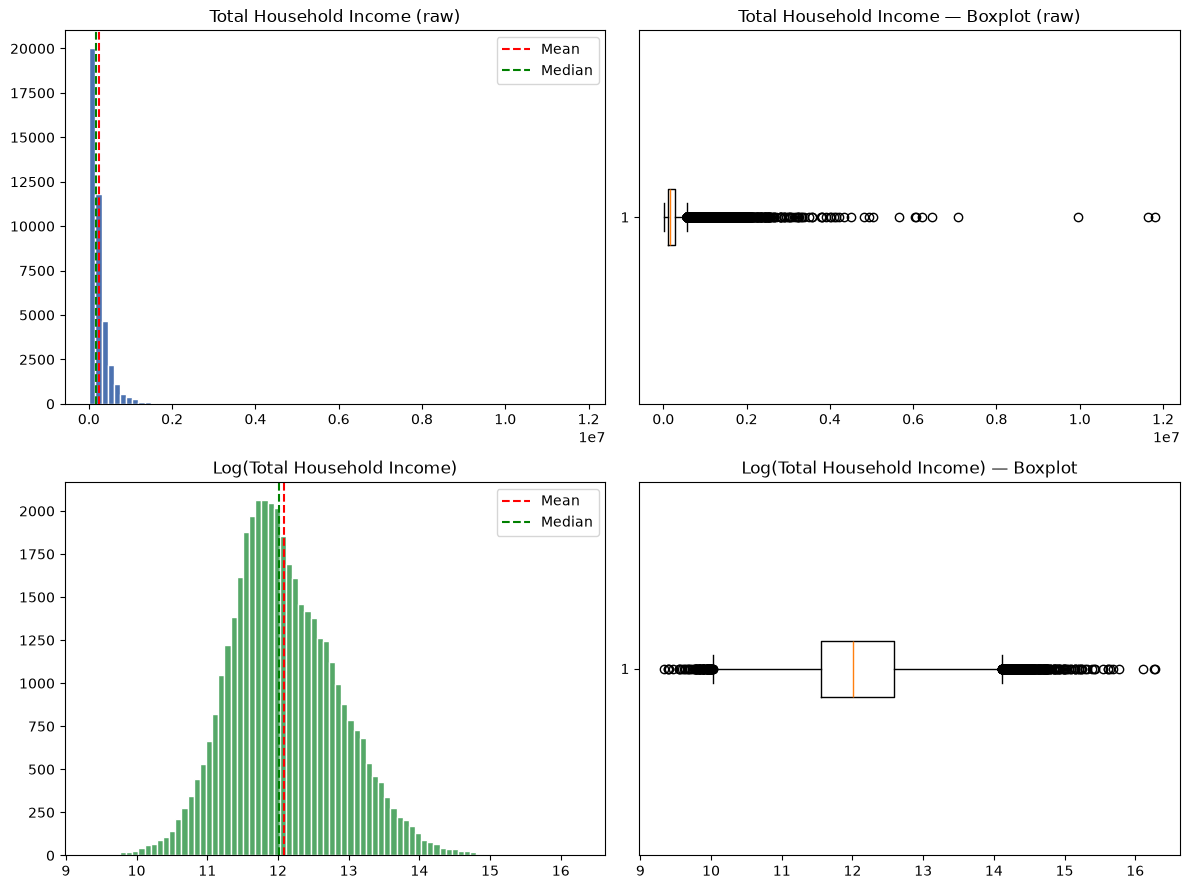

In [21]:
print("Skewness (raw income):", fies_df["Total Household Income"].skew())
print("Skewness (log income):", fies_df["Log Total Household Income"].skew())
print("Mean:", fies_df["Total Household Income"].mean(), "| Median:", fies_df["Total Household Income"].median())

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].hist(fies_df["Total Household Income"], bins=80, color="#4C72B0", edgecolor="white")
axes[0, 0].axvline(fies_df["Total Household Income"].mean(), color="red", linestyle="--", label="Mean")
axes[0, 0].axvline(fies_df["Total Household Income"].median(), color="green", linestyle="--", label="Median")
axes[0, 0].set_title("Total Household Income (raw)")
axes[0, 0].legend()

axes[0, 1].boxplot(fies_df["Total Household Income"], vert=False)
axes[0, 1].set_title("Total Household Income — Boxplot (raw)")

axes[1, 0].hist(fies_df["Log Total Household Income"], bins=80, color="#55A868", edgecolor="white")
axes[1, 0].axvline(fies_df["Log Total Household Income"].mean(), color="red", linestyle="--", label="Mean")
axes[1, 0].axvline(fies_df["Log Total Household Income"].median(), color="green", linestyle="--", label="Median")
axes[1, 0].set_title("Log(Total Household Income)")
axes[1, 0].legend()

axes[1, 1].boxplot(fies_df["Log Total Household Income"], vert=False)
axes[1, 1].set_title("Log(Total Household Income) — Boxplot")

plt.tight_layout()
plt.savefig("income_skew_evidence.png", dpi=150)
plt.show()

# Sanity-check Household Head Age — Keep + Flag (not drop, not cap)

There are 43 rows (0.1% of the sample) with a Household Head Age under 18:
 - 41 rows are aged 15–17
 - 2 rows are aged 9 and 10 (the extreme outliers worth a closer manual look)

 **Why keep instead of drop:** 43 rows out of 41,544 has virtually no effect
 on regression coefficients or ANOVA results, so there's no statistical
 upside to removing them. For the 15–17 group specifically, teen
 heads-of-household are a real, documented phenomenon in the Philippines
 (e.g. an older sibling taking on that role after a parent's death or
 absence) — that's relevant signal for a paper about income vulnerability,
 not noise. Dropping it would quietly bias the sample away from exactly the
 kind of vulnerable household this study cares about.

 **Why not cap:** Forcing ages below 18 up to some floor value would
 fabricate data that didn't happen, and there's no real analytical benefit
 here — capping is more justified for continuous outcome variables (like
 income) where you want to dampen the influence of extreme values while
 keeping the row in-sample. Age isn't the outcome being modeled, so
 reshaping it isn't necessary.

 **Why flag:** A boolean flag lets you (a) run the regression once on the
 full sample and once excluding flagged rows as a robustness check —
 reportable in the paper as "results were consistent with/without these
 cases" — and (b) keep the 9- and 10-year-old rows visible rather than
 silently deleted, in case closer inspection later suggests they're genuine
 data-entry errors worth excluding individually.


In [22]:
suspect_age = fies_df[fies_df["Household Head Age"] < 18]
print(f"{len(suspect_age)} rows with Household Head Age < 18")
print(suspect_age["Household Head Age"].value_counts().sort_index())
suspect_age[["Household Head Age", "Region", "Total Household Income",
             "Household Head Job or Business Indicator"]]
 
# %%
# Flag rather than drop or cap.
fies_df["Suspect Age Flag"] = fies_df["Household Head Age"] < 18
print(fies_df["Suspect Age Flag"].sum(), "rows flagged")


43 rows with Household Head Age < 18
Household Head Age
9      1
10     1
13     2
14     1
15     6
16    19
17    13
Name: count, dtype: int64
43 rows flagged


# Sanity-check Household Head Age
Inspect implausible ages (e.g., household heads under 18) before treating
age as a clean regression predictor.


In [24]:
fies_df.to_csv("../data/preprocessed/preprocessed-fies.csv", index=False)

print("Saved cleaned dataset:", fies_df.shape)


Saved cleaned dataset: (41544, 63)
